# Composer Demo — MalthusJAX

The **Composer** is the highest-level entry-point in MalthusJAX.  
It sits on top of the 3-level hierarchy and wires everything together:  

| Layer | What it does | Composer interface |
|---|---|---|
| **Level 1** – Genomes & Fitness | Genome types, fitness evaluators | `fitness="sphere:dim=10"` |
| **Level 2** – Operators | Selection, crossover, mutation | `selection="tournament:..."` |
| **Level 3** – Engine | Full evolutionary loop | `engine_type="ga"` (via EngineRegistry) |
| **Composer** | Declarative experiment runner | `Composer.quick_run(...)` |

This notebook covers:
1. **OperatorCatalog** — browse, instantiate, and register operators by string spec
2. **EngineRegistry** — browse, instantiate, and register engines by string spec
3. **Composer.quick_run()** — one-liner experiments with MalthusJAX and evosax backends
4. **Engine factories** — lower-level `build_engine` and `build_evosax_engine`
5. **Cross-engine comparison** — same initial population, same seed, two backends
6. **Visualization** — convergence curves from the results

In [1]:
import jax
import jax.random as jr
import matplotlib.pyplot as plt

from malthusjax.composer import Composer, EngineRegistry, build_evosax_engine, list_strategies
from malthusjax.composer.catalog import OperatorCatalog
from malthusjax.composer.engine_factory import build_engine

print(f"JAX version : {jax.__version__}")
print(f"JAX backend : {jax.default_backend()}")

JAX version : 0.8.0
JAX backend : cpu


In [2]:
# Reload modules modified during this session to ensure the notebook picks up edits
import importlib

import malthusjax.benchmarking.runner as runner_mod
import malthusjax.composer.composer as comp
import malthusjax.composer.engine_catalog as ec
import malthusjax.composer.engine_factory as ef
import malthusjax.composer.engine_registry as er
import malthusjax.composer.evosax_adapter as ea
import malthusjax.core.random as rng_mod
import malthusjax.engine as engine_pkg
import malthusjax.engine.genetic_fastengine as gfe

importlib.reload(rng_mod)
importlib.reload(runner_mod)
importlib.reload(gfe)
importlib.reload(ef)
importlib.reload(er)
importlib.reload(engine_pkg)  # Re-runs _register_engines() after registry was cleared
importlib.reload(ec)
importlib.reload(ea)
importlib.reload(comp)
print("Reloaded all engine + composer modules")

Reloaded all engine + composer modules


In [3]:
# Shared initial population for fair backend comparison
DIM, POP_SIZE = 10, 50
BOUNDS = (-5.0, 5.0)
SEED = jr.PRNGKey(123)
INIT_POP = jr.uniform(SEED, (POP_SIZE, DIM), minval=BOUNDS[0], maxval=BOUNDS[1])
print(f"Shared INIT_POP shape: {INIT_POP.shape}")

Shared INIT_POP shape: (50, 10)


---
## 1  OperatorCatalog — browsing and instantiation

Every operator in MalthusJAX is registered in the **catalog** and can
be created from a plain string spec: `"name:param1=val1,param2=val2"`.

In [4]:
catalog = OperatorCatalog()

# All registered keys, grouped for readability
available = catalog.list_available()
print(f"Total registered keys: {len(available)}\n")
for name in available:
    print(f"  • {name}")

Total registered keys: 36

  • ball
  • ball_injection
  • bbob
  • binary_sum
  • binomial
  • binomial_injection
  • bitflip
  • blend
  • blend_injection
  • elite_pool
  • evosax_de
  • evosax_gaussian
  • evosax_mr15
  • evosax_simplega
  • evosax_uniform_crossover
  • gaussian
  • gaussian_injection
  • griewank
  • knapsack
  • polynomial
  • polynomial_injection
  • rastrigin
  • roulette
  • scramble
  • simulated_binary
  • simulated_binary_injection
  • single_point
  • sphere
  • sphere_maximize
  • sphere_minimize
  • swap
  • tournament
  • tsp
  • uniform_binary
  • uniform_real
  • uniform_real_injection


In [5]:
# Instantiate operators from string specs
sel = catalog.get("tournament:num_selections=25,tournament_size=3")
cx = catalog.get("blend:alpha=0.5")
mut = catalog.get("gaussian:mutation_rate=0.1")
fit = catalog.get("sphere:dim=10")

print(f"Selection : {type(sel).__name__}  (num_selections={sel.num_selections})")
print(f"Crossover : {type(cx).__name__}   (alpha={cx.alpha})")
print(f"Mutation  : {type(mut).__name__}  (rate={mut.mutation_rate})")
print(f"Fitness   : {type(fit).__name__}")

Selection : TournamentSelection  (num_selections=25)
Crossover : BlendCrossover   (alpha=0.5)
Mutation  : GaussianMutation  (rate=0.1)
Fitness   : BBOBEvaluator


In [6]:
# Defaults kick in when you omit parameters
sel_default = catalog.get("tournament")
print(
    f"Default tournament → num_selections={sel_default.num_selections}, "
    f"tournament_size={sel_default.tournament_size}"
)

# Parse a spec without instantiating
name, params = catalog.parse_spec("bbob:fn_name=rastrigin,dim=5,seed=99")
print(f"\nParsed spec → name={name!r}, params={params}")

Default tournament → num_selections=4, tournament_size=3

Parsed spec → name='bbob', params={'fn_name': 'rastrigin', 'dim': 5, 'seed': 99}


---
## 1b  EngineRegistry — browsing and instantiation

Just as operators have the `OperatorCatalog`, engines now have the
**EngineRegistry**.  Engines self-register at import time and can be
resolved from a string spec: `"engine_name:param1=val1,param2=val2"`.

The `EngineRegistry` is the engine counterpart of `OperatorCatalog`.
Use it when you need to:
- List available engine types
- Instantiate engines by name with parameter overrides
- Register custom engines at runtime

In [7]:
engine_registry = EngineRegistry()

# All registered engine names
available_engines = engine_registry.list_available()
print(f"Registered engines: {available_engines}\n")

# Parse a spec without instantiating
name, params = engine_registry.parse_spec("ga:pop_size=200,elitism=4")
print(f"Parsed spec → name={name!r}, params={params}")

# Get help/documentation for an engine
print(f"\n{engine_registry.get_help('ga')}")

Registered engines: ['ga']

Parsed spec → name='ga', params={'pop_size': 200, 'elitism': 4}

ga
--

Standard genetic algorithm (GeneticEngine).

        Wraps :class:`GeneticEngine` in a
        :class:`~malthusjax.composer.engine_factory.GeneticEngineAdapter`
        compatible with the BenchmarkRunner protocol.
        

Defaults: pop_size=50, generations=100, elitism=2, genome_type=real


In [8]:
# Instantiate an engine directly from the registry
engine = engine_registry.get(
    "ga:pop_size=30,elitism=1",
    evaluator=catalog.get("sphere:dim=5"),
    selection=catalog.get("tournament:num_selections=15,tournament_size=3"),
    crossover=catalog.get("blend:alpha=0.5"),
    mutation=catalog.get("gaussian:mutation_rate=0.1"),
    generations=10,
    genome_length=5,
)

res = engine.run_once(jr.PRNGKey(0))
print(f"EngineRegistry.get('ga:...') → best fitness: {res['summary']['best_fitness']:.6f}")
print(
    f"  pop_size={engine.genetic_engine.engine_params.pop_size}, "
    f"elitism={engine.genetic_engine.engine_params.elitism}"
)

EngineRegistry.get('ga:...') → best fitness: -44.479542
  pop_size=30, elitism=1


---
## 2  Composer.quick_run() — one-liner experiments

`quick_run()` is the recommended entry-point. It accepts:
- **`engine_type="ga"`** (default) — selects engine from the EngineRegistry, 
  supports spec overrides like `"ga:elitism=4"`
- **`backend="malthusjax"`** (default) — wires Level 1–3 operators via the catalog  
- **`backend="evosax"`** — wraps an evosax strategy with ask/tell  
- Falls back to a **StubEngine** when no operators are given

In [9]:
composer = Composer.create_default()

GENS = 10  # shared generation budget for fair comparison

# --- MalthusJAX backend ------------------------------------------------
result_malthus = composer.quick_run(
    backend="malthusjax",
    fitness="sphere:dim=10",
    selection="tournament:num_selections=25,tournament_size=3",
    crossover="blend:alpha=0.5",
    mutation="gaussian:mutation_rate=0.1",
    pop_size=POP_SIZE,
    generations=GENS,
    genome_length=DIM,
    seeds=(42,),
    experiment_name="demo_malthusjax",
    initial_population=INIT_POP,
)

run = result_malthus.runs[0]
print("MalthusJAX backend")
print(f"  Best fitness  : {run.metrics['best_fitness']:.6f}")
print(f"  Generations   : {run.metrics['final_generation']:.0f}")
print(f"  Total evals   : {run.metrics['total_evaluations']:.0f}")

seeds: 100%|██████████| 1/1 [00:04<00:00,  4.28s/it]

MalthusJAX backend
  Best fitness  : -47.972553
  Generations   : 10
  Total evals   : 500


In [10]:
# --- Evosax backend ----------------------------------------------------
result_evosax = composer.quick_run(
    backend="evosax",
    evosax_strategy="SimpleGA",
    fitness="sphere:dim=10",
    pop_size=POP_SIZE,
    generations=GENS,
    genome_length=DIM,
    seeds=(42,),
    experiment_name="demo_evosax",
    initial_population=INIT_POP,
)

run_e = result_evosax.runs[0]
print("Evosax backend (SimpleGA)")
print(f"  Best fitness  : {run_e.metrics['best_fitness']:.6f}")
print(f"  Generations   : {run_e.metrics['final_generation']:.0f}")
print(f"  Total evals   : {run_e.metrics['total_evaluations']:.0f}")

seeds: 100%|██████████| 1/1 [00:01<00:00,  1.18s/it]

Evosax backend (SimpleGA)
  Best fitness  : 67.473320
  Generations   : 10
  Total evals   : 500


---
## 3  Convergence comparison

Both backends return the same `{history, summary, timings}` dict,  
so we can overlay their convergence curves directly.

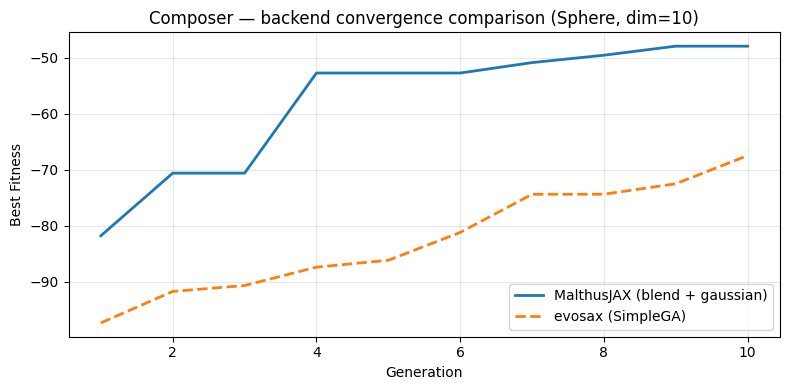

[{'generation': 1, 'best_fitness': -81.7845458984375, 'mean_fitness': -152.0761260986328}, {'generation': 2, 'best_fitness': -70.61785888671875, 'mean_fitness': -127.49495697021484}, {'generation': 3, 'best_fitness': -70.61785888671875, 'mean_fitness': -98.78684997558594}, {'generation': 4, 'best_fitness': -52.76065444946289, 'mean_fitness': -81.11053466796875}, {'generation': 5, 'best_fitness': -52.76065444946289, 'mean_fitness': -73.30052947998047}, {'generation': 6, 'best_fitness': -52.76065444946289, 'mean_fitness': -65.91248321533203}, {'generation': 7, 'best_fitness': -50.90388870239258, 'mean_fitness': -60.84963607788086}, {'generation': 8, 'best_fitness': -49.58492660522461, 'mean_fitness': -56.39109420776367}, {'generation': 9, 'best_fitness': -47.97255325317383, 'mean_fitness': -54.0754280090332}, {'generation': 10, 'best_fitness': -47.97255325317383, 'mean_fitness': -51.74982452392578}]


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

gens_m = [h["generation"] for h in run.history]
best_m = [h["best_fitness"] for h in run.history]

gens_e = [h["generation"] for h in run_e.history]
best_e = [h["best_fitness"] * -1 for h in run_e.history]

ax.plot(gens_m, best_m, label="MalthusJAX (blend + gaussian)", linewidth=2)
ax.plot(gens_e, best_e, label="evosax (SimpleGA)", linewidth=2, linestyle="--")

ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness")
ax.set_title("Composer — backend convergence comparison (Sphere, dim=10)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(run.history)

---
## 4  Lower-level engine factories

When you need more control, use `build_engine` and `build_evosax_engine` directly.

In [12]:
# build_engine: pass operator instances or string specs
adapter = build_engine(
    fitness_evaluator=catalog.get("sphere:dim=5"),
    selection_op=catalog.get("roulette:num_selections=25"),
    crossover_op=catalog.get("simulated_binary"),
    mutation_op=catalog.get("polynomial"),
    pop_size=50,
    generations=80,
    genome_shape=(5,),
    bounds=(-5.0, 5.0),
)

res = adapter.run_once(jr.PRNGKey(0))
print(f"build_engine → best fitness: {res['summary']['best_fitness']:.6f}")

build_engine → best fitness: -44.412128


In [13]:
# build_evosax_engine: direct factory for an evosax adapter
evosax_adapter = build_evosax_engine(
    strategy_name="DifferentialEvolution",
    evaluator=catalog.get("rastrigin:dim=10"),
    pop_size=64,
    generations=150,
    bounds=(-5.12, 5.12),
    maximize=False,
)

res_de = evosax_adapter.run_once(jr.PRNGKey(7))
print(f"DE on Rastrigin → best fitness: {res_de['summary']['best_fitness']:.6f}")

DE on Rastrigin → best fitness: 89.510544


---
## 5  Available evosax strategies

In [14]:
print("Registered evosax strategies:")
for s in list_strategies():
    print(f"  • {s}")

Registered evosax strategies:
  • DifferentialEvolution
  • MR15_GA
  • SimpleGA


---
## 6  Cross-engine comparison with shared initial population

For a fair comparison, inject the **same initial population** into both
backends so the only difference is the evolutionary strategy.

In [15]:
DIM, POP_SIZE, GENS = 10, 50, 100
BOUNDS = (-5.0, 5.0)
SEED = jr.PRNGKey(123)

# Shared initial population
INIT_POP = jr.uniform(SEED, (POP_SIZE, DIM), minval=BOUNDS[0], maxval=BOUNDS[1])
print(f"Initial population shape: {INIT_POP.shape}")

Initial population shape: (50, 10)


In [16]:
# MalthusJAX with initial_population
adapter_m = build_engine(
    fitness_evaluator=catalog.get("sphere:dim=10"),
    selection_op=catalog.get("tournament:num_selections=25,tournament_size=3"),
    crossover_op=catalog.get("blend:alpha=0.5"),
    mutation_op=catalog.get("gaussian:mutation_rate=0.1"),
    pop_size=POP_SIZE,
    generations=GENS,
    genome_shape=(DIM,),
    bounds=BOUNDS,
    initial_population=INIT_POP,
)

# Evosax with the same initial_population
adapter_e = build_evosax_engine(
    strategy_name="SimpleGA",
    evaluator=catalog.get("sphere:dim=10"),
    pop_size=POP_SIZE,
    generations=GENS,
    bounds=BOUNDS,
    maximize=False,
    initial_population=INIT_POP,
)

KEY = jr.PRNGKey(0)
res_e = adapter_e.run_once(KEY)

print(f"Evosax     final best: {res_e['summary']['best_fitness']:.6f}")

res_m = adapter_m.run_once(KEY)
print(f"MalthusJAX final best: {res_m['summary']['best_fitness']:.6f}")

Evosax     final best: 49.018967
MalthusJAX final best: -44.411896


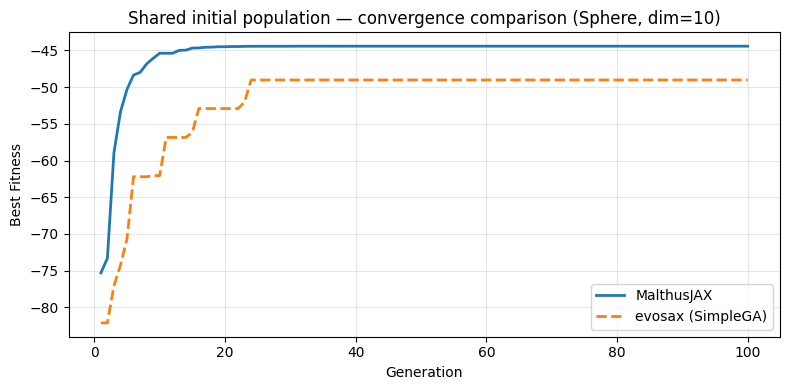

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    [h["generation"] for h in res_m["history"]],
    [h["best_fitness"] for h in res_m["history"]],
    label="MalthusJAX",
    linewidth=2,
)
ax.plot(
    [h["generation"] for h in res_e["history"]],
    [h["best_fitness"] * -1 for h in res_e["history"]],
    label="evosax (SimpleGA)",
    linewidth=2,
    linestyle="--",
)

ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness")
ax.set_title("Shared initial population — convergence comparison (Sphere, dim=10)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7  Swapping operators via the catalog

One of the main advantages of the Composer is rapid operator swapping.  
Here we compare two crossover strategies on the same problem.

In [18]:
crossovers = {
    "Blend (α=0.5)": "blend:alpha=0.5",
    "SBX (η=2)": "simulated_binary:eta=2.0",
    "Binomial (cr=0.9)": "binomial:crossover_rate=0.9",
}

results = {}
for label, cx_spec in crossovers.items():
    eng = build_engine(
        fitness_evaluator=catalog.get("sphere:dim=10"),
        selection_op=catalog.get("tournament:num_selections=25,tournament_size=3"),
        crossover_op=catalog.get(cx_spec),
        mutation_op=catalog.get("gaussian:mutation_rate=0.1"),
        pop_size=50,
        generations=100,
        genome_shape=(10,),
        bounds=(-5.0, 5.0),
    )
    results[label] = eng.run_once(jr.PRNGKey(42))

for label, r in results.items():
    print(f"{label:25s}  best={r['summary']['best_fitness']:.6f}")

Blend (α=0.5)              best=-44.411919
SBX (η=2)                  best=-44.411896
Binomial (cr=0.9)          best=-44.412663


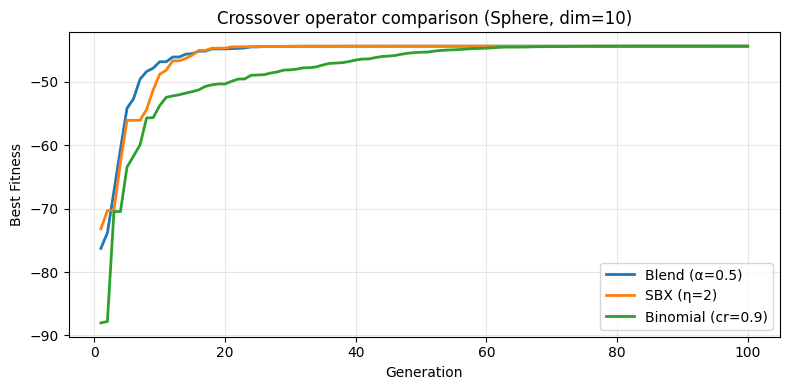

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, r in results.items():
    gens = [h["generation"] for h in r["history"]]
    best = [h["best_fitness"] for h in r["history"]]
    ax.plot(gens, best, label=label, linewidth=2)

ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness")
ax.set_title("Crossover operator comparison (Sphere, dim=10)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8  Choosing the PRNG algorithm

JAX supports several PRNG backends.  Pass `prng_impl=` to `quick_run()` or
`build_engine()` to select one:

| Name | Best for | Notes |
|---|---|---|
| `"threefry"` | CPU, reproducibility | Default; deterministic across platforms |
| `"philox"` | GPU throughput | Counter-based; better GPU utilisation |
| `"rbg"` | Speed (non-splittable) | Hardware RNG; not splittable |
| `"unsafe_rbg"` | Max speed (unsafe) | Like `rbg` but skips safety checks |

In [20]:
from malthusjax.core.random import PRNGImpl

# Show all available PRNG implementations
print("Available PRNG implementations:")
for impl in PRNGImpl:
    print(f"  • {impl.name.lower():12s}  →  JAX backend: {impl.value}")
print()

# Run the same experiment with two different PRNG backends
composer = Composer.create_default()

for prng in ("threefry", "unsafe_rbg"):
    result = composer.quick_run(
        backend="malthusjax",
        fitness="sphere:dim=10",
        selection="tournament:num_selections=25,tournament_size=3",
        crossover="blend:alpha=0.5",
        mutation="gaussian:mutation_rate=0.1",
        pop_size=POP_SIZE,
        generations=50,
        genome_length=DIM,
        seeds=(42,),
        experiment_name=f"prng_{prng}",
        prng_impl=prng,
    )
    best = result.runs[0].metrics["best_fitness"]
    print(f"  prng_impl={prng:10s}  →  best_fitness = {best:.6f}")

Available PRNG implementations:
  • threefry      →  JAX backend: threefry2x32
  • philox        →  JAX backend: philox4x32_10
  • rbg           →  JAX backend: rbg
  • unsafe_rbg    →  JAX backend: unsafe_rbg



seeds: 100%|██████████| 1/1 [00:02<00:00,  2.14s/it]


  prng_impl=threefry    →  best_fitness = -44.412670


seeds: 100%|██████████| 1/1 [00:02<00:00,  2.19s/it]

  prng_impl=unsafe_rbg  →  best_fitness = -44.412460


---
## 9  Registering a custom operator at runtime

The catalog is extensible — register any callable that accepts `**kwargs`.

In [21]:
from malthusjax.operators.mutation.real import GaussianMutation


def my_aggressive_mutation(**kwargs):
    """Pre-configured aggressive Gaussian mutation."""
    kwargs.setdefault("mutation_rate", 0.5)
    kwargs.setdefault("mutation_strength", 2.0)
    return GaussianMutation(**kwargs)


catalog.register("aggressive_gaussian", my_aggressive_mutation)

# Verify registration
op = catalog.get("aggressive_gaussian")
print(f"Custom operator: {type(op).__name__}")
print(f"  mutation_rate     = {op.mutation_rate}")
print(f"  mutation_strength = {op.mutation_strength}")

# Override defaults via the spec string
op2 = catalog.get("aggressive_gaussian:mutation_rate=0.8")
print(f"\nOverridden mutation_rate = {op2.mutation_rate}")

Custom operator: GaussianMutation
  mutation_rate     = 0.5
  mutation_strength = 2.0

Overridden mutation_rate = 0.8


---
## 10 Data-Driven Evaluators (Option C)

MalthusJAX now supports data-driven combinatorial evaluators using the `DataLoader` and `DataRegistry`.
This allows loading external metrics (e.g., CSV, NPZ, TSPLIB) and linking them to fitness functions like `tsp`.

In [26]:
import csv

from malthusjax.composer.composer import Composer

# 1. Create a dummy TSPLIB-like CSV distance matrix
with open("temp_tsp.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([0, 10, 15, 20])
    writer.writerow([10, 0, 35, 25])
    writer.writerow([15, 35, 0, 30])
    writer.writerow([20, 25, 30, 0])

# 2. Define the data config mapping an arbitrary ID to the file
data_config = {"my_matrix": {"source": "file", "path": "temp_tsp.csv"}}

# 3. Run Composer targeting the DataID (tsp evaluator expects a data_id)
composer = Composer()
metrics = composer.quick_run(
    fitness="tsp:data_id=my_matrix",
    data_config=data_config,
    pop_size=20,
    num_gens=10,
    genome_size=4,  # 4 cities
)

print(metrics.aggregated_summary())

seeds: 100%|██████████| 3/3 [00:03<00:00,  1.31s/it]

{'initial_fitness': {'mean': 150.0, 'median': 150.0, 'stdev': 0.0}, 'best_fitness': {'mean': 150.0, 'median': 150.0, 'stdev': 0.0}, 'final_generation': {'mean': 100.0, 'median': 100.0, 'stdev': 0.0}, 'total_evaluations': {'mean': 2000.0, 'median': 2000.0, 'stdev': 0.0}}


---
## Summary

| API | When to use |
|---|---|
| `Composer.quick_run()` | Rapid prototyping, multi-seed experiments |
| `OperatorCatalog.get()` | Browse / swap operators by string spec |
| `EngineRegistry.get()` | Browse / swap engine types by string spec |
| `build_engine()` | Full control over the MalthusJAX engine |
| `build_evosax_engine()` | Wrap any evosax strategy for benchmarking |
| `catalog.register()` | Add custom or pre-configured operators |
| `engine_registry.register()` | Add custom engine types |